In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
from torchvision.utils import save_image
import torchvision.transforms as transforms
import io
import numpy as np
from zipp import zipfile
from tqdm import tqdm
from time import sleep
from PIL import Image
from torchvision import datasets, transforms
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.utils as vutils
from torch import nn, Tensor
from typing import Tuple, Union, Any, List
from abc import abstractmethod


In [ ]:
# Install Kaggle package
!pip install kaggle

In [ ]:
# Set up Kaggle API credentials (You need to get your Kaggle API Key from your Kaggle account settings page)

os.environ['KAGGLE_USERNAME'] = "test0101"
os.environ['KAGGLE_KEY'] = "64f4bbaaa06efeebfeb4d6ad121"

# Download the dataset from Kaggle
!kaggle datasets download -d splcher/animefacedataset
!kaggle datasets download -d brendanartley/cartoon-faces-googles-cartoon-set

# Unzip the downloaded files if needed
!unzip -q animefacedataset.zip -d animefacedataset
!unzip -q cartoon-faces-googles-cartoon-set.zip -d cartoon_faces_dataset

# Now you can proceed to load and work with the datasets


Dataset URL: https://www.kaggle.com/datasets/splcher/animefacedataset
License(s): DbCL-1.0
100% 394M/395M [00:18<00:00, 21.7MB/s]
100% 395M/395M [00:18<00:00, 22.2MB/s]
Dataset URL: https://www.kaggle.com/datasets/brendanartley/cartoon-faces-googles-cartoon-set
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.34G/2.34G [01:58<00:00, 21.1MB/s]
100% 2.34G/2.34G [01:58<00:00, 21.2MB/s]


In [ ]:
dataset_anime_dir = './animefacedataset/images/'
dataset_cartoon_dir = './cartoon_faces_dataset/cartoonset100k_jpg/'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 5
device

device(type='cuda')

In [ ]:
class AnimeDataset(Dataset):
    def __init__(self, path_file, dataset_anime_dir, transform=None):
        self.images = []
        self.trans = transforms.Compose([transforms.Resize((64, 64)),  transforms.ToTensor()])
        self.transform = transform
        for file in path_file:
            img = Image.open(dataset_anime_dir+file)
            self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.trans(self.images[i])
        if self.transform:
            img = self.transform(img)
        return img

In [ ]:
# Load the Anime Face dataset and display 5 random pictures
dir_anime = os.listdir(dataset_anime_dir)
selected_images = random.sample(dir_anime, 5)
selected_images

['34252_2011.jpg',
 '61780_2018.jpg',
 '20331_2007.jpg',
 '10612_2005.jpg',
 '62908_2019.jpg']

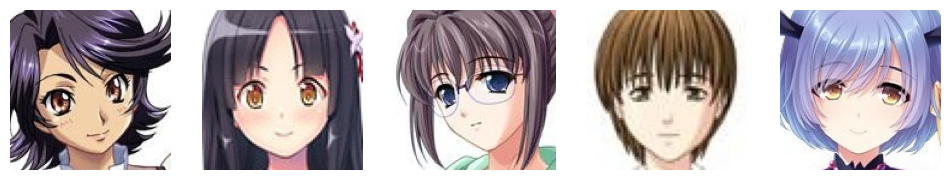

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(5):
    img_path = os.path.join(dataset_anime_dir, selected_images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
dataset_anime = AnimeDataset(dir_anime, dataset_anime_dir)

In [ ]:
# Create Dataloader
dataloader_anime = DataLoader(dataset_anime, batch_size=batch_size, shuffle=True)

In [ ]:
# Define the VAE model
class VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)

        # Decoder
        self.fc_decoder = nn.Linear(latent_dim, 128*8*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        x = self.fc_decoder(z)
        x = x.view(x.size(0), 128, 8, 8)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Define the loss function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss(reduction='sum')(recon_x, x)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_divergence


In [ ]:
model_vae = VAE().to(device)
optimizer = optim.Adam(model_vae.parameters(), lr=1e-3)
# Train the model
recon_losses = []
#kl_losses = []

In [ ]:
for epoch in range(num_epochs):
    total_recon_loss = 0
    total_kl_divergence = 0
    for i, (images) in enumerate(tqdm(dataloader_anime)):
        images = images.to(device)
        recon_images, mu, logvar = model_vae(images)
        recon_loss = vae_loss(recon_images, images, mu, logvar)

        optimizer.zero_grad()
        recon_loss.backward()
        optimizer.step()
        total_recon_loss += recon_loss.item()

    recon_losses.append(total_recon_loss / len(dataloader_anime))
    print(f"Epoch {epoch+1}/{num_epochs}, Reconstruction Loss: {recon_losses[-1]}")


100%|██████████| 994/994 [00:49<00:00, 19.89it/s]


Epoch 1/5, Reconstruction Loss: 23776.160665654083


100%|██████████| 994/994 [00:31<00:00, 32.05it/s]


Epoch 2/5, Reconstruction Loss: 18259.674395494058


100%|██████████| 994/994 [00:31<00:00, 31.34it/s]


Epoch 3/5, Reconstruction Loss: 17491.601231903136


100%|██████████| 994/994 [00:30<00:00, 32.21it/s]


Epoch 4/5, Reconstruction Loss: 17190.348792707417


100%|██████████| 994/994 [00:31<00:00, 31.51it/s]

Epoch 5/5, Reconstruction Loss: 17015.145115320833


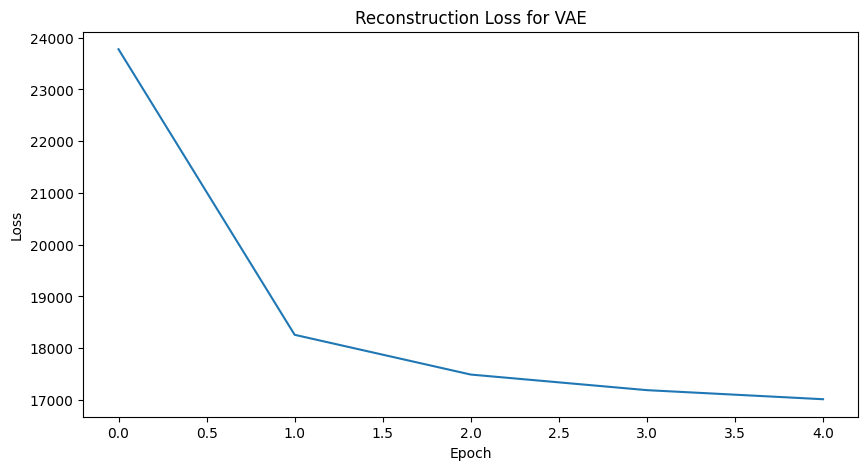

In [ ]:
# Plot the loss values
plt.figure(figsize=(10, 5))
plt.plot(recon_losses)
plt.title("Reconstruction Loss for VAE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


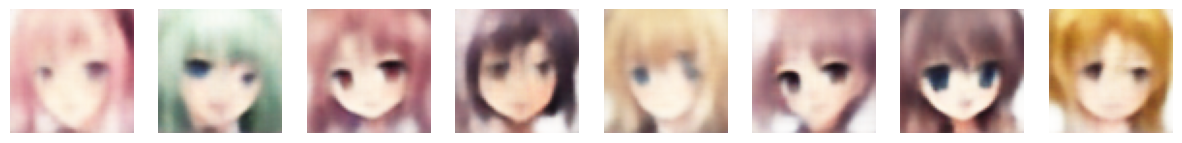

In [ ]:
# Generate 8 noises and produce images
noise = torch.randn(8, model_vae.latent_dim).to(device)
generated_images = model_vae.decode(noise).cpu().detach().numpy()

plt.figure(figsize=(15, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    img = np.transpose(generated_images[i], (1, 2, 0))
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
# Define the VAE model
class VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)

        # Decoder
        self.fc_decoder = nn.Linear(latent_dim, 128*8*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        x = self.fc_decoder(z)
        x = x.view(x.size(0), 128, 8, 8)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Define the loss function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss(reduction='sum')(recon_x, x)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_divergence


In [ ]:
class AnimeDataset2(Dataset):
    def __init__(self, path_file, dataset_anime_dir, transform=None):
        self.path_file = path_file
        self.dataset_anime_dir = dataset_anime_dir
        self.transform = transform
        self.trans = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])

    def __len__(self):
        return len(self.path_file)

    def __getitem__(self, i):
        img_path = os.path.join(self.dataset_anime_dir, self.path_file[i])
        img = Image.open(img_path)
        img = self.trans(img)
        if self.transform:
            img = self.transform(img)
        return img

In [ ]:
# Cartoon faces Dataset
folders = os.listdir(dataset_cartoon_dir)
selected_folders = random.sample(folders, 5)
selected_folders

['2', '4', '9', '1', '6']

In [ ]:
images = []
for folder in selected_folders:
    folder_path = os.path.join(dataset_cartoon_dir, folder)
    images.extend([os.path.join(folder_path, img) for img in os.listdir(folder_path)])

In [ ]:
len(images)

50000

In [ ]:
dataset_cartoon = AnimeDataset2(images, dataset_anime_dir='')

In [ ]:
dataloader_cartoon = DataLoader(dataset_cartoon, batch_size=batch_size, shuffle=True)

In [ ]:
model_car = VAE().to(device)
optimizer = optim.Adam(model_car.parameters(), lr=1e-3)
# Train the model
losses = []

In [ ]:
for epoch in range(num_epochs):
    total_loss = 0
    for i, (images) in enumerate(tqdm(dataloader_cartoon)):
        images = images.to(device)
        recon_images, mu, logvar = model_car(images)
        loss = vae_loss(recon_images, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss / len(dataloader_cartoon))
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {losses[-1]}")


100%|██████████| 782/782 [02:34<00:00,  5.06it/s]


Epoch 1/5, Loss: 10932.10765977162


100%|██████████| 782/782 [02:26<00:00,  5.34it/s]


Epoch 2/5, Loss: 4174.334953366643


100%|██████████| 782/782 [02:26<00:00,  5.34it/s]


Epoch 3/5, Loss: 3424.4790718878626


100%|██████████| 782/782 [02:26<00:00,  5.35it/s]


Epoch 4/5, Loss: 3121.191424669817


100%|██████████| 782/782 [02:25<00:00,  5.36it/s]

Epoch 5/5, Loss: 2920.24984780236


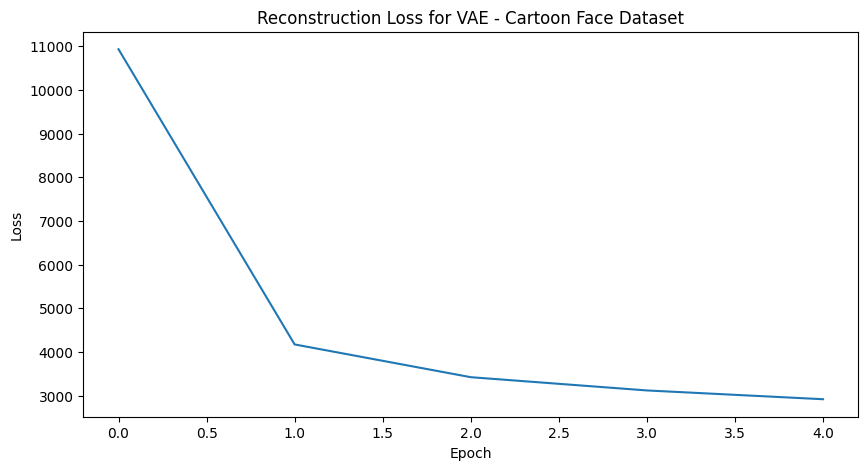

In [ ]:
# Plot the loss values
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Reconstruction Loss for VAE - Cartoon Face Dataset")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


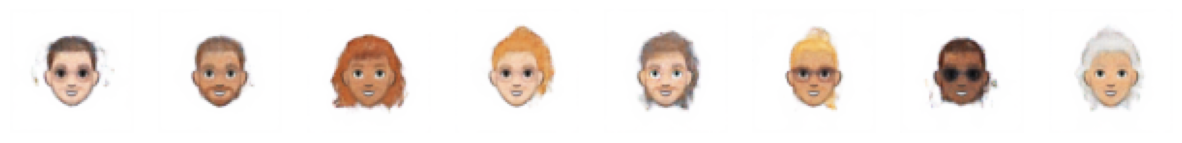

In [ ]:
# Generate 8 noises and produce images
noise = torch.randn(8, model_car.latent_dim).to(device)
generated_images_cartoon = model_car.decode(noise).cpu().detach().numpy()

plt.figure(figsize=(15, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    img = np.transpose(generated_images_cartoon[i], (1, 2, 0))
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
# Dividing the AnimeDataset into half with label 0
class HalfAnimeDataset(Dataset):
    def __init__(self, dataset, label):
        self.data = dataset
        self.label = label

    def __len__(self):
        return len(self.data) // 2

    def __getitem__(self, i):
        return self.data[i], self.label

# Dividing the CartoonDataset into half with label 1
class HalfCartoonDataset(Dataset):
    def __init__(self, dataset, label):
        self.data = dataset
        self.label = label

    def __len__(self):
        return len(self.data) // 2

    def __getitem__(self, i):
        return self.data[i], self.label


In [ ]:
# Combining the two half datasets
combined_dataset = HalfAnimeDataset(dataset_anime, 0) + HalfCartoonDataset(dataset_cartoon, 1)
combined_dataset


In [ ]:
len(combined_dataset.datasets[0])

31782

In [ ]:
len(combined_dataset.datasets[1])

25000

In [ ]:
dataloader_combined = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
class CVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, condition_dim):
        super(CVAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.condition_dim = condition_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim + condition_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.z_mean = nn.Linear(64, latent_dim)
        self.z_log_var = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x, c):
        encoder_input = torch.cat((x, c), dim=1)
        enc = self.encoder(encoder_input)
        mu = self.z_mean(enc)
        log_var = self.z_log_var(enc)
        z = self.reparameterize(mu, log_var)

        decoder_input = torch.cat((z, c), dim=1)
        x_recon = self.decoder(decoder_input)

        return x_recon, mu, log_var

In [ ]:
# Initialize the CVAE model
input_dim = 64*64*3
latent_dim = 20
condition_dim = 1
cvae = CVAE(input_dim, latent_dim, condition_dim).to(device)

# Define the loss function
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

# Define the optimizer
optimizer = torch.optim.Adam(cvae.parameters(), lr=0.001)

In [ ]:
# Training the CVAE model
losses = []
cvae.train()
for epoch in range(num_epochs):
  total_loss = 0
  for batch_idx, (data, label) in enumerate(tqdm(dataloader_combined)):
    data = data.to(device)
    label = label.to(device)
    data = data.view(data.size(0), -1)
    label = label.view(label.size(0), -1).float()
    recon_data, mu, log_var = cvae(data, label)
    loss = loss_function(recon_data, data, mu, log_var)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  losses.append(total_loss / len(dataloader_combined.dataset))
  print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {losses[-1]}')



100%|██████████| 888/888 [01:21<00:00, 10.89it/s]


Epoch 1/5, Average Loss: 5074.907825240613


100%|██████████| 888/888 [01:23<00:00, 10.69it/s]


Epoch 2/5, Average Loss: 4810.593849475847


100%|██████████| 888/888 [01:22<00:00, 10.74it/s]


Epoch 3/5, Average Loss: 4729.633322124529


100%|██████████| 888/888 [01:23<00:00, 10.67it/s]


Epoch 4/5, Average Loss: 4689.164513718586


100%|██████████| 888/888 [01:23<00:00, 10.63it/s]

Epoch 5/5, Average Loss: 4662.997705864094


In [ ]:
def generate_images(model, num_samples, label):
    model.eval()
    with torch.no_grad():
        fixed_label = torch.full((num_samples, 1), label, device=device)
        fixed_noise = torch.randn(
                (num_samples, latent_dim), device=device)

        fake_images = model.decoder(torch.cat((fixed_noise, fixed_label), dim=1))
        fake_images = fake_images.view(fake_images.size(0), 3, 64, 64)

        save_image = vutils.make_grid(fake_images, nrow=num_samples // 2)
        save_image = save_image.mul(255).clamp(0, 255).byte().permute(1, 2, 0).cpu().numpy()

        plt.imshow(save_image)
        plt.axis('off')
        plt.show()


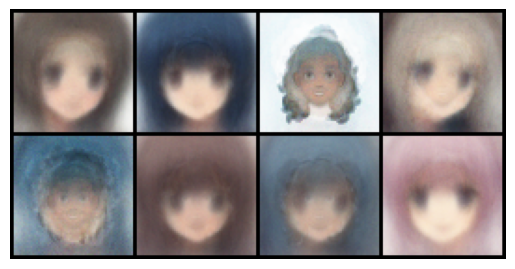

In [ ]:
num_samples = 8
label = 0
generate_images(cvae, num_samples, label)

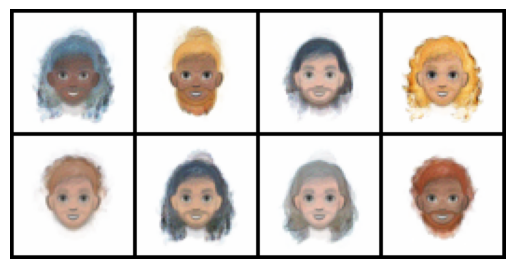

In [ ]:
label = 1
generate_images(cvae, num_samples, label)

# **VQ-VAE**

In [ ]:
class EncoderBuilder:
    def build_encoder(self, in_channels, embedding_dim, hidden_dims):
        modules = []

        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, out_channels=h_dim, kernel_size=4, stride=2, padding=1),
                    nn.LeakyReLU()
                )
            )
            in_channels = h_dim

        modules.append(nn.Sequential(nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1), nn.LeakyReLU()))

        for _ in range(6):
            modules.append(CustomLayer(in_channels, in_channels))
            modules.append(nn.LeakyReLU())

        modules.append(nn.Sequential(nn.Conv2d(in_channels, embedding_dim, kernel_size=1, stride=1), nn.LeakyReLU()))

        return modules

class DecoderBuilder:
    def build_decoder(self, embedding_dim, hidden_dims):
        modules = []
        modules.append(nn.Sequential(nn.Conv2d(embedding_dim, hidden_dims[-1], kernel_size=3, stride=1, padding=1), nn.LeakyReLU()))

        for _ in range(6):
            modules.append(CustomLayer(hidden_dims[-1], hidden_dims[-1]))
            modules.append(nn.LeakyReLU())

        hidden_dims.reverse()

        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(nn.ConvTranspose2d(hidden_dims[i], hidden_dims[i + 1], kernel_size=4, stride=2, padding=1),
                              nn.LeakyReLU())
            )

        modules.append(
            nn.Sequential(nn.ConvTranspose2d(hidden_dims[-1], out_channels=3, kernel_size=4, stride=2, padding=1), nn.Tanh())
        )

        return modules

class CustomVQ(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int, beta: float = 0.25):
        super(CustomVQ, self).__init__()
        self.K = num_embeddings
        self.D = embedding_dim
        self.beta = beta
        self.embedding = nn.Embedding(self.K, self.D)
        self.embedding.weight.data.uniform_(-1 / self.K, 1 / self.K)
        self.embedding = self.embedding.to(device)

    def forward(self, latents: Tensor) -> Tensor:
        latents = latents.permute(0, 2, 3, 1).contiguous()
        latents_shape = latents.shape
        flat_latents = latents.view(-1, self.D)
        flat_latents = flat_latents.to(device)

        dist = torch.sum(flat_latents ** 2, dim=1, keepdim=True) + \
               torch.sum(self.embedding.weight ** 2, dim=1) - \
               2 * torch.matmul(flat_latents, self.embedding.weight.t())
        dist = dist.to(device)

        encoding_inds = torch.argmin(dist, dim=1).unsqueeze(1)
        encoding_inds = encoding_inds.to(device)
        encoding_one_hot = torch.zeros(encoding_inds.size(0), self.K, device=device)
        encoding_one_hot = encoding_one_hot.to(device)
        encoding_one_hot.scatter_(1, encoding_inds, 1)

        quantized_latents = torch.matmul(encoding_one_hot, self.embedding.weight)
        quantized_latents = quantized_latents.view(latents_shape)

        commitment_loss = F.mse_loss(quantized_latents.detach(), latents)
        embedding_loss = F.mse_loss(quantized_latents, latents.detach())
        vq_loss = commitment_loss * self.beta + embedding_loss

        quantized_latents = latents + (quantized_latents - latents).detach()
        return quantized_latents.permute(0, 3, 1, 2).contiguous(), vq_loss


In [ ]:
class CustomLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super(CustomLayer, self).__init__()
        self.resblock = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                                      nn.ReLU(True),
                                      nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False))
        self.resblock = self.resblock.to(device)

    def forward(self, input: Tensor) -> Tensor:
        return input + self.resblock(input)

class VQVAE(nn.Module):
    def __init__(self, in_channels: int, num_embeddings: int, embedding_dim: int, hidden_dims: List = None,
                 beta: float = 0.25, img_size: int = 64, **kwargs) -> None:

        super(VQVAE, self).__init__()

        self.cfg = {
            'in_channels': in_channels,
            'num_embeddings': num_embeddings,
            'embedding_dim': embedding_dim,
            'hidden_dims': hidden_dims if hidden_dims is not None else [128, 256],
            'beta': beta,
            'img_size': img_size
        }

        self.encoder_builder = EncoderBuilder()
        self.decoder_builder = DecoderBuilder()

        self.init()

    def init(self):
        in_channels = self.cfg['in_channels']
        num_embeddings = self.cfg['num_embeddings']
        embedding_dim = self.cfg['embedding_dim']
        hidden_dims = self.cfg['hidden_dims']
        beta = self.cfg['beta']

        self.encoder, self.decoder, self.vq_layer = self._build_vqvae(in_channels, embedding_dim, hidden_dims, num_embeddings, beta)

    def _build_vqvae(self, in_channels, embedding_dim, hidden_dims, num_embeddings, beta):
        encoder_modules = self.encoder_builder.build_encoder(in_channels, embedding_dim, hidden_dims)
        encoder = nn.Sequential(*encoder_modules).to(device)

        vq_layer = CustomVQ(num_embeddings, embedding_dim, beta).to(device)

        decoder_modules = self.decoder_builder.build_decoder(embedding_dim, hidden_dims)
        decoder = nn.Sequential(*decoder_modules).to(device)

        return encoder, decoder, vq_layer

    def forward(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        x = self.encoder(x)
        quantized, vq_loss = self.vq_layer(x)
        x_recon = self.decoder(quantized)
        return x_recon, vq_loss

In [ ]:
vq_vae = VQVAE(in_channels=3, num_embeddings=512, embedding_dim=64)
vq_vae = vq_vae.to(device)

optimizer = optim.Adam(vq_vae.parameters(), lr=1e-4)
losses_vq_vae = []


In [ ]:
for epoch in range(num_epochs):
    vq_vae.train()
    total_loss = 0.0

    for data in tqdm(dataloader_anime):
        data = data.to(device)
        x_recon, vq_loss = vq_vae(data)
        recon_loss = F.mse_loss(x_recon, data)
        loss = recon_loss + vq_loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses_vq_vae.append(total_loss / len(dataloader_anime.dataset))
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {losses_vq_vae[-1]}')

100%|██████████| 994/994 [02:28<00:00,  6.67it/s]


Epoch 1/5, Average Loss: 0.07251433913626669


100%|██████████| 994/994 [02:27<00:00,  6.73it/s]


Epoch 2/5, Average Loss: 0.012016094994149509


100%|██████████| 994/994 [02:27<00:00,  6.74it/s]


Epoch 3/5, Average Loss: 0.00041719531508693444


100%|██████████| 994/994 [02:28<00:00,  6.70it/s]


Epoch 4/5, Average Loss: 0.00030794400264075555


100%|██████████| 994/994 [02:27<00:00,  6.73it/s]

Epoch 5/5, Average Loss: 0.00027956672931161937


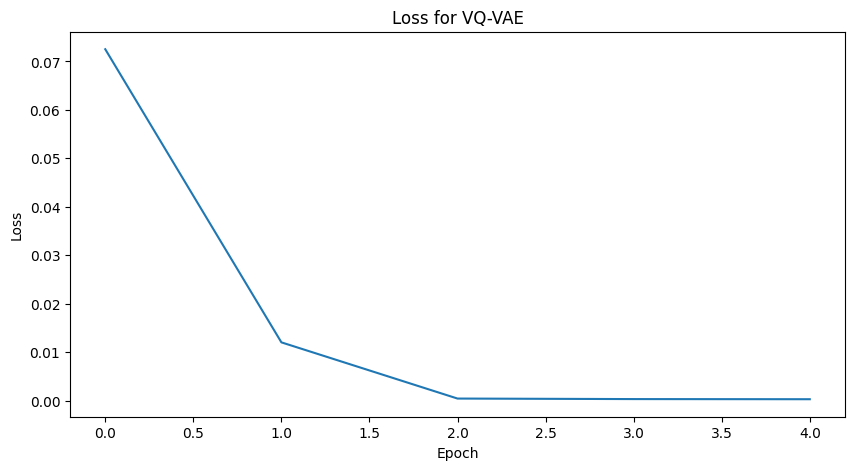

In [ ]:
# Plot the loss values
plt.figure(figsize=(10, 5))
plt.plot(losses_vq_vae)
plt.title("Loss for VQ-VAE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Get some data from the dataloader
data_iter = iter(dataloader_anime)
images = next(data_iter)

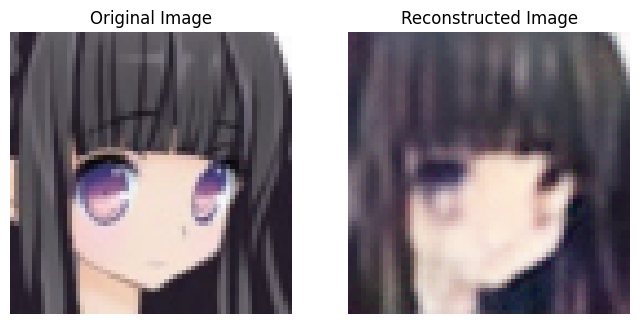

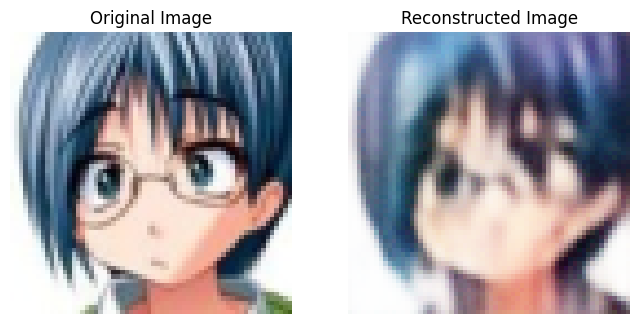

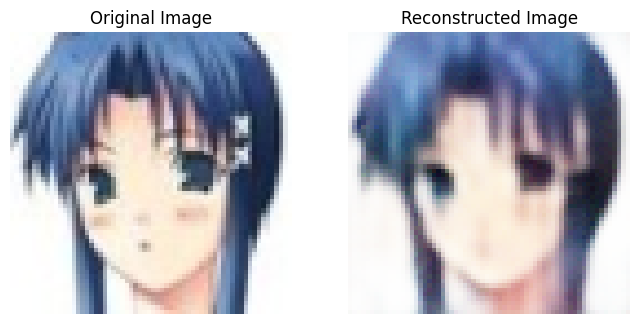

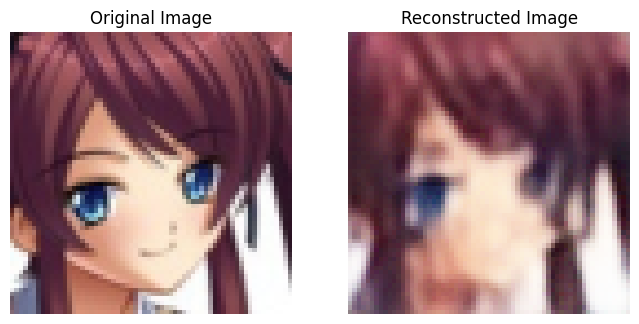

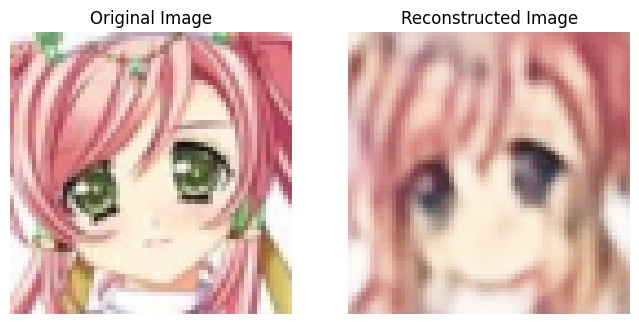

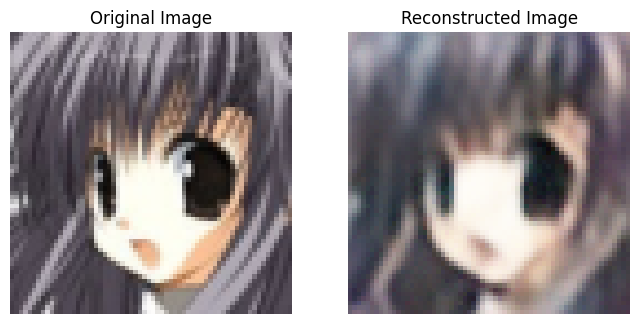

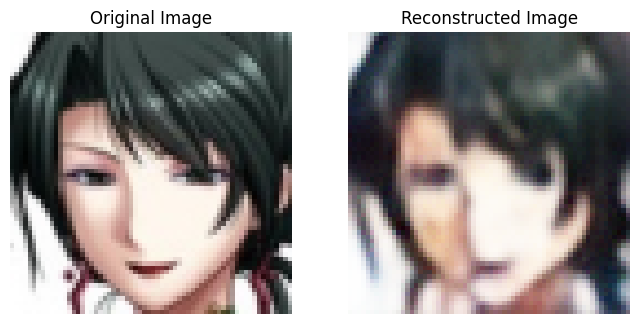

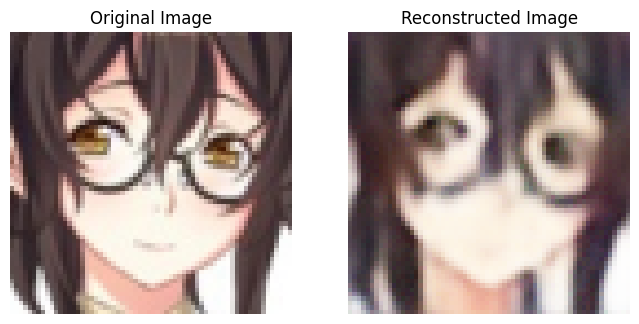

In [ ]:
# Put the model in evaluation mode
vq_vae.eval()
# Display the original and reconstructed images
with torch.no_grad():
    reconstructed_images, _ = vq_vae(images.to(device))
    reconstructed_images = reconstructed_images.clip(0, 1)

    num_images = min(8, len(images))

    for i in range(num_images):
        plt.figure(figsize=(8, 4))

        # Original image
        plt.subplot(1, 2, 1)
        plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
        plt.title('Original Image')
        plt.axis('off')

        # Reconstructed image
        plt.subplot(1, 2, 2)
        plt.imshow(reconstructed_images[i].permute(1, 2, 0).cpu().numpy())
        plt.title('Reconstructed Image')
        plt.axis('off')

        plt.show()


In [ ]:
generated_images_tensor = torch.tensor(generated_images).to(device)

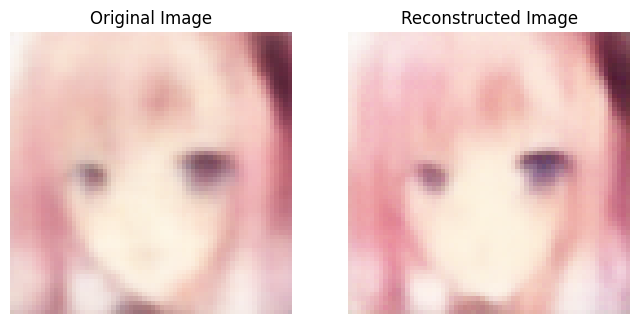

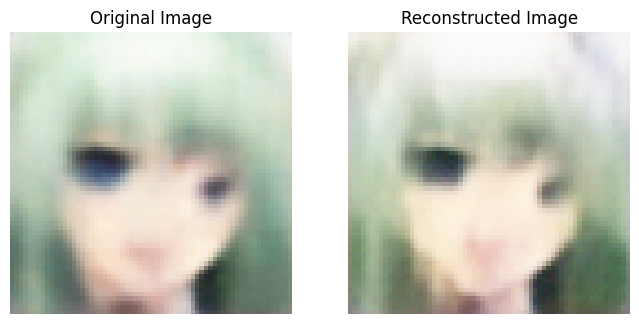

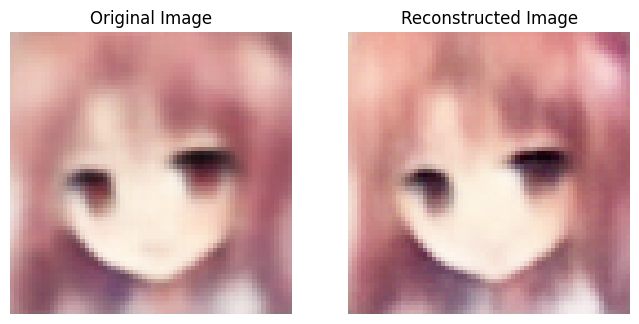

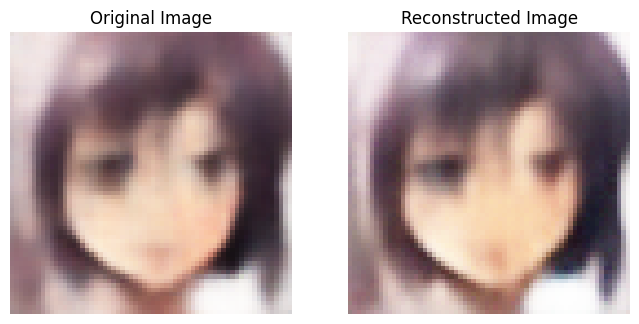

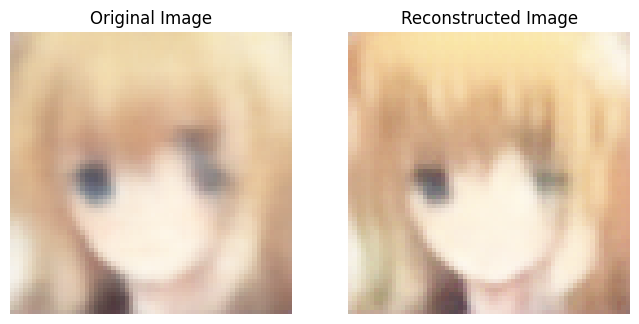

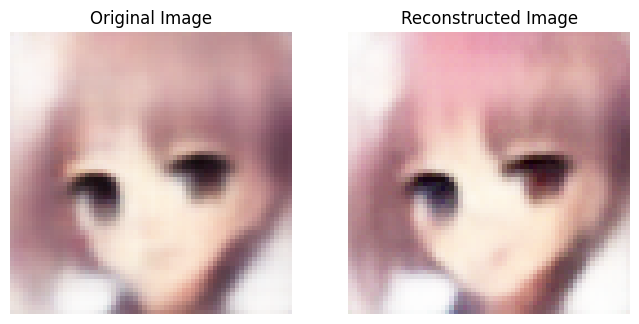

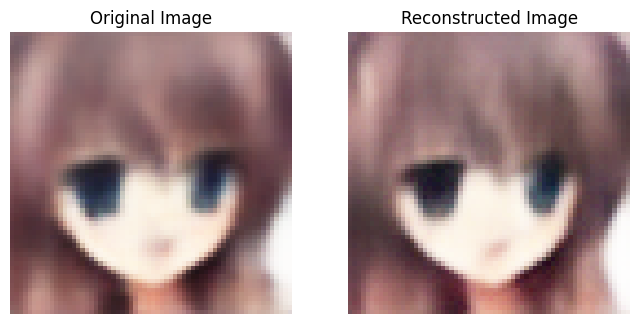

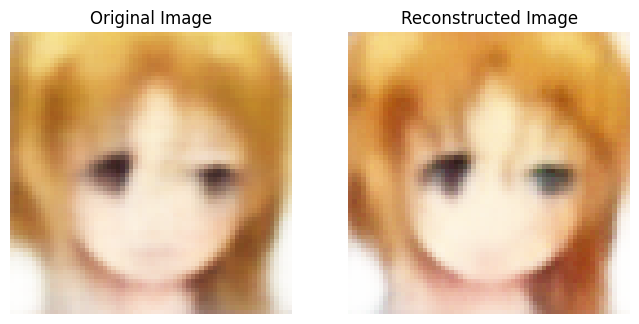

In [ ]:
# Put the model in evaluation mode
vq_vae.eval()
# Display the original and reconstructed images
with torch.no_grad():
    reconstructed_images, _ = vq_vae(generated_images_tensor)
    reconstructed_images = reconstructed_images.clip(0, 1)

    num_images = min(8, len(images))

    for i in range(len(generated_images)):
        plt.figure(figsize=(8, 4))

        # Original image
        plt.subplot(1, 2, 1)
        plt.imshow(generated_images_tensor[i].permute(1, 2, 0).cpu().numpy())
        plt.title('Original Image')
        plt.axis('off')

        # Reconstructed image
        plt.subplot(1, 2, 2)
        plt.imshow(reconstructed_images[i].permute(1, 2, 0).cpu().numpy())
        plt.title('Reconstructed Image')
        plt.axis('off')

        plt.show()
